# Regressão

Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>
Copyright: Creative Commons

<hr>

## Regressão linear simples

Vamos supor que temos o conjunto de dados abaixo.

In [580]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

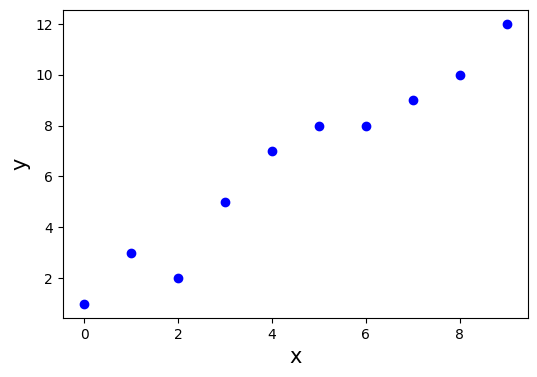

In [581]:
# define os dados
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12])
plt.figure(figsize=(6,4))
plt.plot(x, y, 'bo')
plt.xlabel("x", fontsize = 15)
plt.ylabel("y", fontsize = 15)
plt.show(True)

Vemos que é uma relação entre as variáveis $X$ e $Y$. Queremos determinar um modelo que melhor descreva essa relação. Podemos supor um modelo de regressão linear simples, como:
$$
y_i \approx \beta_0 + \beta_1x_i
$$

Como há outros fatores, além de $x_i$ que afetam os valores de $y_i$, podemos escrever:
$$
y_i = \beta_0 + \beta_1 x_i + \epsilon_i,
$$
onde $\epsilon_i$ é uma variável aleatória que indica **o erro na aproximação.** O objetivo dos métodos de regressão é encontrar o melhor valor de $\beta_0$ e $\beta_1$ que minimizem o erro no ajuste. Ou seja, queremos encontrar a linha no plano $xy$ que melhor se ajuste aos dados observados.

Estimando os coeficiente através do método dos momentos ou dos mínimos quadrados, obtemos:
    $$
    \begin{cases}
    \hat{\beta}_1=\frac{\sum_{i=1}^n (x_i- \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} = \frac{S{xy}}{S{xx}}\\
    \hat{\beta}_0= \bar{y}-\hat{\beta_1}\bar{x}
    \end{cases}
    $$

Vamos implementar uma função para realizar a estimação.

In [582]:
from statistics import variance
import math

def estimate_coef(x, y):
    # número de observações/pontos
    n = np.size(x)

    # médias de x e y
    mx, my = np.mean(x), np.mean(y)

    # calculating cross-deviation and deviation about x
    #SS_xy = np.sum(y*x) - n*m_y*m_x
    #SS_xx = np.sum(x*x) - n*m_x*m_x
    Sxx = 0
    Sxy = 0
    for i in range(0,len(x)):
        Sxy = Sxy + (x[i]-mx)*(y[i]-my)
        Sxx = Sxx + (x[i]-mx)**2

    # calcula os coeficientes de regressão
    b1 = Sxy / Sxx
    b0 = my - b1*mx
    return(b0, b1)

# função para mostrar os dados e o ajuste linear
def plot_regression_line(x, y, b):
    # mostra os dados
    plt.scatter(x, y, color = "b", marker = "o", s = 50)

    # prediz os valores
    y_pred = b[0] + b[1]*x

    # mostra a reta de regressão
    plt.plot(x, y_pred, color = "r")
    plt.xlabel('x', fontsize = 15)
    plt.ylabel('y', fontsize = 15)
    plt.show(True)

Assim, aplicando ao conjunto de dados:

Estimated coefficients:
b_0 = 1.2363636363636363  
b_1 = 1.1696969696969697


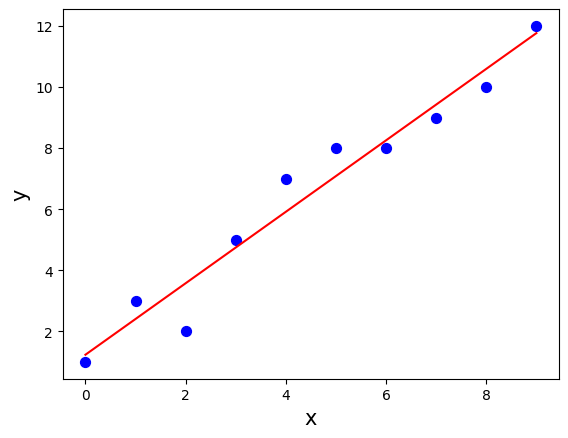

In [583]:
import numpy as np

# estima os coeficientes
b = estimate_coef(x, y)
print("Estimated coefficients:\nb_0 = {}  \nb_1 = {}".format(b[0], b[1]))

# mostra o ajuste linear
plot_regression_line(x, y, b)

Para quantificar a acurácia do modelo, usamos o erro padrão residual (residual standard error):
$$
RSE = \sqrt{\frac{1}{n-2}\sum_{i=1}^n (y_i-\hat{y}_i)^2}
$$

In [584]:
#funcao que calcula o RSE
def RSE(x,y,b):
    n = len(y)
    RSE = 0
    for i in range(0,n):
        y_pred = b[0]+ x[i]*b[1] # valor predito
        RSE = RSE + (y[i]-y_pred)**2
    RSE = math.sqrt(RSE/(n-2))
    return RSE
print('RSE:', RSE(x,y,b))

RSE: 0.8384690232980003


Outra medida importante é o coeficiente R2, que **mede a proporção da variabilidade em Y que pode ser explicada a partir de X.**
$$
R^2 = 1-\frac{\sum_{i=1}^n (y_i-\hat{y}_i)^2}{\sum_{i=1}^n(y_i-\bar{y})^2}, \quad 0\leq R^2\leq 1
$$

In [585]:
def R2(x,y,b):
    n = len(y)
    c1 = 0
    c2 = 0
    ym = np.mean(y)
    for i in range(0,n):
        y_pred = b[0]+ x[i]*b[1] # valor predito
        c1 = c1 + (y[i]-y_pred)**2
        c2 = c2 + (y[i]-ym)**2
    R2 = 1 - c1/c2
    return R2

print('R2:', R2(x,y,b))

R2: 0.952538038613988


Quanto mais próximo de um, melhor é o ajuste da regressão linear.

O coeficiente de determinação $R^2$ é igual ao quadrado do coeficiente de correlação de Pearson ao quadrado na regressão linear simples (uma única variável independente $X$ prevendo $Y$).

In [586]:
from scipy.stats import pearsonr

print('Pearson ao quadrado:', pearsonr(x,y)[0]**2)

Pearson ao quadrado: 0.9525380386139878


O código completo:

Coeficientes:
b_0 = 1.2363636363636363  
b_1 = 1.1696969696969697
R2: 0.952538038613988


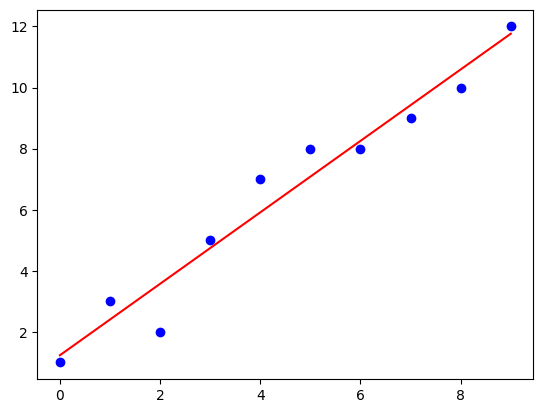

In [587]:
import matplotlib.pyplot as plt
import numpy as np
from statistics import variance
import math

# define os dados
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12])

# funcao que estima os coeficientes
def estimate_coef(x, y):
    # número de observações
    n = np.size(x)
    # estimadores
    m_x, m_y = np.mean(x), np.mean(y)
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x
    # calcula os coeficientes de regressão
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x
    return(b_0, b_1)

# função para mostrar os dados e o ajuste linear
def plot_regression_line(x, y, b):
    # mostra os dados
    plt.scatter(x, y, color = "b", marker = "o", s = 50)
    # prediz os valores
    y_pred = b[0] + b[1]*x
    # mostra a reta de regressão
    plt.plot(x, y_pred, color = "r")
    plt.xlabel('x', fontsize = 15)
    plt.ylabel('y', fontsize = 15)
    plt.show(True)

def R2(x,y,b):
    n = len(y)
    c1 = 0
    c2 = 0
    ym = np.mean(y)
    for i in range(0,n):
        y_pred = b[0]+ x[i]*b[1] # valor predito
        c1 = c1 + (y[i]-y_pred)**2
        c2 = c2 + (y[i]-ym)**2
    R2 = 1 - c1/c2
    return R2

# estima os coeficientes
b = estimate_coef(x, y)
print("Coeficientes:\nb_0 = {}  \nb_1 = {}".format(b[0], b[1]))
print('R2:', R2(x,y,b))


# mostra o ajuste linear
plt.plot(x,y,'bo')
plt.plot(x, b[0] + b[1]*x, 'r-')
plt.savefig('plot.eps')

## Regressão linear múltipla

Para o caso multivariado, vimos que a estimação dos coeficientes pelo método dos mínimos quadrados resulta na relação:
$$
\beta = (\text{X}^T \text{X})^{-1} \text{X}^T \text{y}
$$
onde
$$
\text{X} = \begin{pmatrix}
1 & x_{11} &x_{12} &\ldots &x_{1d} \\
1 & x_{21} &x_{22} &\ldots &x_{2d} \\
\ldots & \ldots &\ldots &\ldots &\ldots \\
1 & x_{n1} &x_{n2} &\ldots &x_{nd} \\
\end{pmatrix}
$$

Vamos considerar dados reais e a biblioteca scikit-learn. Inicialmente, carregamos os dados.

In [588]:
import pandas as pd
import matplotlib.pyplot as plt

# le os dados
# se for lear do hard disk: ############################
data = pd.read_csv('data/Advertising.csv', header=(0), index_col=[0])

# Se for lear do Google Drive: ############################
#rom google.colab import drive
#drive.mount('/content/drive/')

#file_path = '/content/drive/MyDrive/data/Advertising.csv'
#try:
#    data = pd.read_csv(file_path)
#    print(data.head()) # Print the first 5 rows of the DataFrame
#except FileNotFoundError:
#    print(f"Error: The file was not found at {file_path}")
############################



# valor a ser predito
ylabel = data.columns[-1]
print("Número de linhas e colunas:", data.shape)
data.head(10)

Número de linhas e colunas: (200, 4)


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,2.1,1.0,4.8
10,199.8,2.6,21.2,10.6


Transformos os dados para o formato numpy para facilitar o acesso.

In [589]:
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

Selecionamos os conjuntos de teste e treinamento, sendo que $p$% dos dados serão usados como teste e (1-p)%, como treinamento.

In [590]:
from sklearn.model_selection import train_test_split
# divide o conjunto em treinamento e teste
p = 0.2 # fracao e elementos no conjnto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p, random_state = 42)

O ajuste dos coeficientes da regressão linear é feito usando apenas o conjunto de treinamento.

In [591]:
from sklearn.linear_model import LinearRegression

# modelo de regressão linear múltipla
lm = LinearRegression()
lm.fit(X_train, y_train)

y_pred = lm.predict(X_test)

Notem que como temos várias variáveis, não é possível mostrar os resultados em mais de três dimensões. Nesse caso, uma maneira de visualizar a precisão na predição é graficar os valores reais versus as predições, como mostramos abaixo.

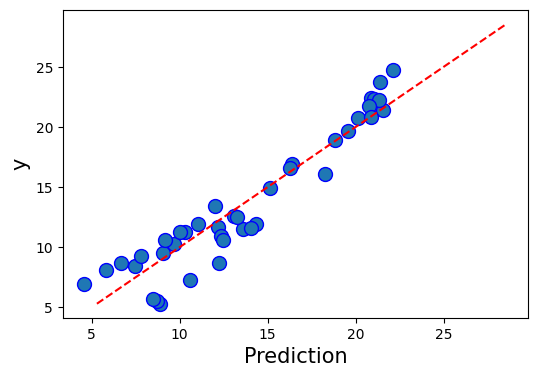

In [592]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6,4))
l = plt.plot(y_pred, y_test, 'bo')
plt.setp(l, markersize=10)
plt.setp(l, markerfacecolor='C0')

plt.ylabel("y", fontsize=15)
plt.xlabel("Prediction", fontsize=15)

# mostra os valores preditos e originais
xl = np.arange(min(y_test), 1.2*max(y_test),(max(y_test)-min(y_test))/10)
yl = xl
plt.plot(xl, yl, 'r--')

plt.show(True)
# salva a figura em um arquivo
fig.savefig('regression-LR.jpg')

Quanto mais próximo da reta em vermelho, melhor será a predição, pois essa reta representa o caso em que $\hat{y} = y$.

Para quantificarmos o ajuste, calculamos o coeficiente R2.

In [593]:
from sklearn.metrics import r2_score
R2 = r2_score(y_test, y_pred)
print('R2:', R2)

R2: 0.899438024100912


Usando a biblioteca OLS:

In [594]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [595]:
import statsmodels.api as sm

model = sm.OLS(y_train,X_train)
results = model.fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.982
Model:                            OLS   Adj. R-squared (uncentered):              0.982
Method:                 Least Squares   F-statistic:                              2935.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):                   1.28e-137
Time:                        21:21:17   Log-Likelihood:                         -336.65
No. Observations:                 160   AIC:                                      679.3
Df Residuals:                     157   BIC:                                      688.5
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Fazendo a predição no conjunto de teste:

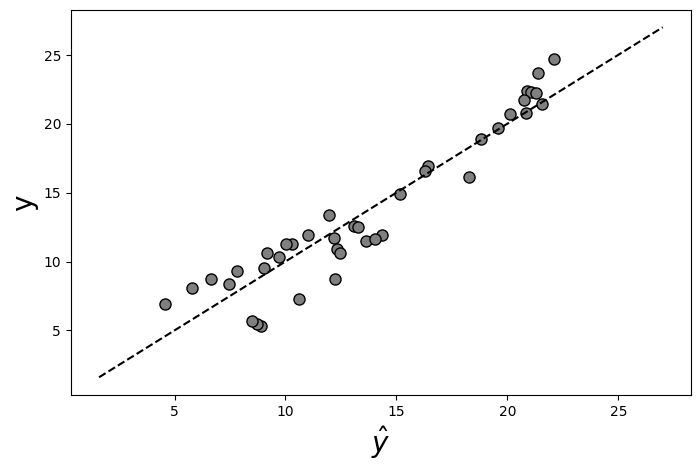

In [596]:
import matplotlib.pyplot as plt
import numpy as np

yhat = results.predict(X_test)

# mostra os resultados
plt.figure(figsize=(8,5))
l = plt.plot(y_pred, y_test, 'o', color='gray', markersize=8,
         markerfacecolor='gray',
         markeredgecolor='black')
# mostra a linha x = y
plt.plot([min(y),max(y)],[min(y),max(y)],
         color = 'black', linestyle='--')
plt.ylabel("y", fontsize=20)
plt.xlabel(r"$\hat{y}$", fontsize=20)
plt.savefig('regression-concrete.svg')
plt.show(True)

## Regressão polinomial

Notem que o modelo não precisa ter termos lineares em X, mas apenas nos parâmetros. Por exemplo, modelo abaixo ainda é linear nos parâmetros: $$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \epsilon$$

Vamos considerar um exemplo.

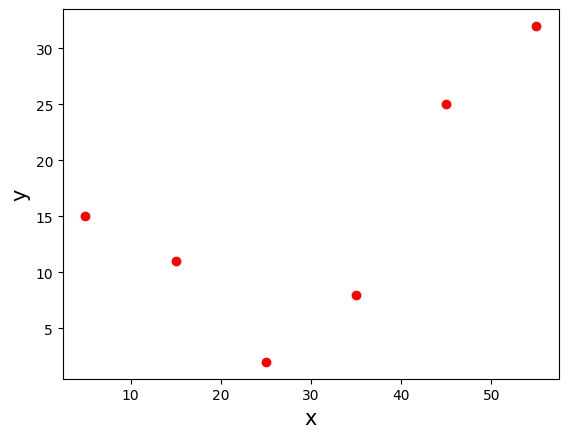

In [597]:
import numpy as np
from sklearn.linear_model import LinearRegression

x = np.array([5, 15, 25, 35, 45, 55])
y = np.array([15, 11, 2, 8, 25, 32])
plt.plot(x,y, 'ro')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)

plt.show(True)

In [598]:
print('x:',  x)
print('y:', y)

x: [ 5 15 25 35 45 55]
y: [15 11  2  8 25 32]


Geramos os dados quadráticos inserindo mais uma coluna.

In [599]:
from sklearn.preprocessing import PolynomialFeatures

# define a transformação nos dados
transformer = PolynomialFeatures(degree=2, include_bias=False)
x = x.reshape((-1, 1))
transformer.fit(x)
print('Dados originais:\n', x)

# transforma os dados incluindo uma nova coluna com valores quadráticos
x_ = transformer.transform(x)
print('Novos dados:\n', x_)

Dados originais:
 [[ 5]
 [15]
 [25]
 [35]
 [45]
 [55]]
Novos dados:
 [[   5.   25.]
 [  15.  225.]
 [  25.  625.]
 [  35. 1225.]
 [  45. 2025.]
 [  55. 3025.]]


O modelo será dado por: $$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \epsilon$$

Vamos aplicar a regressão linear:

In [600]:
model = LinearRegression().fit(x_, y)
y_pred = model.predict(x_)

Mostrando os valores preditos ($\hat{y}$) e os originais ($y$):

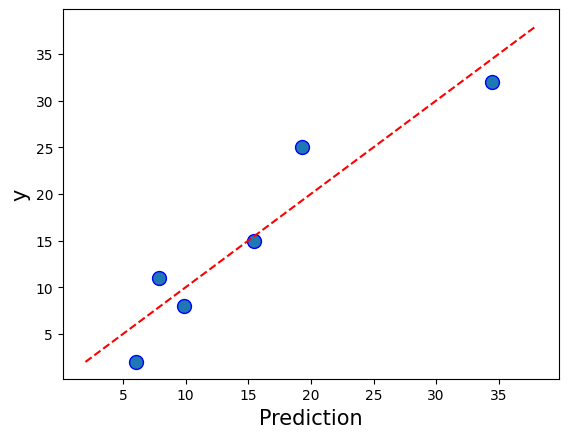

In [601]:
import matplotlib.pyplot as plt

fig = plt.figure()
l = plt.plot(y_pred, y, 'bo')
plt.setp(l, markersize=10)
plt.setp(l, markerfacecolor='C0')

plt.ylabel("y", fontsize=15)
plt.xlabel("Prediction", fontsize=15)

# mostra a reta diagonal, que representa a predição perfeita
xl = np.arange(min(y), 1.2*max(y),(max(y)-min(y))/10)
yl = xl
plt.plot(xl, yl, 'r--')

plt.show(True)

Mostrando os valores no gráfico original:

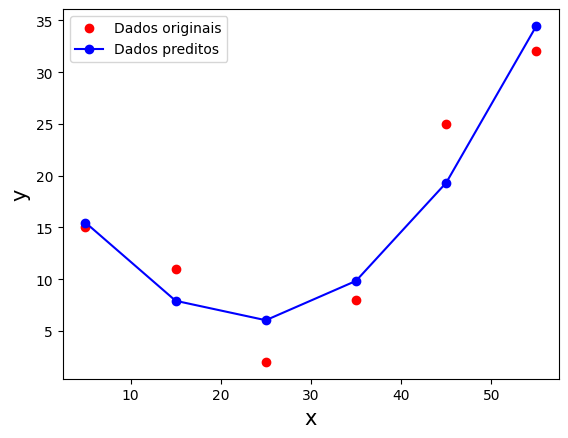

In [602]:
plt.plot(x,y, 'ro', label='Dados originais')
plt.plot(x,y_pred, 'bo-', label = 'Dados preditos')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)
plt.legend()
plt.show(True)

O coeficiente R2:

In [603]:
from sklearn.metrics import r2_score
R2 = r2_score(y, y_pred)
print('R2:', R2)

R2: 0.8908516262498564


Portanto, para ajustar um modelo com variáveis não lineares, basta gerarmos um novo conjunto de dados inserindo novas colunas aos dados originais e realizar o procedimento de regressão multivariada. Cada coluna inserida contém os dados originais elevados a uma potência definida pelos termos do modelo.

## Inferência sobre os parâmetros


Vamos gerar os dados e usar a biblioteca ols para realizar a inferência (https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.OLS.html)

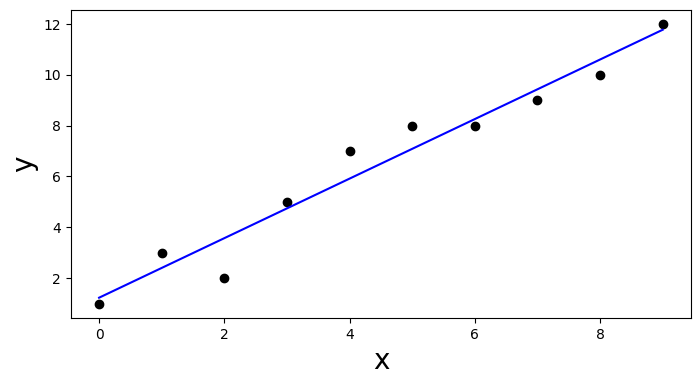

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     160.6
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.41e-06
Time:                        21:21:18   Log-Likelihood:                -11.312
No. Observations:                  10   AIC:                             26.62
Df Residuals:                       8   BIC:                             27.23
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2364      0.493      2.509      0.0

In [604]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.formula.api import ols

# dados
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12])
data = pd.DataFrame({'x': x, 'y': y})

# ajusta o modelo de regressão linear
x = x.reshape(-1, 1)
reg = LinearRegression().fit(x, y)
y_predicted = reg.predict(x)

# mostra os resultados
plt.figure(figsize=(8,4))
plt.plot(x, y, 'o', color='black');
plt.plot(x,y_predicted,color='blue')
plt.xlabel('x', fontsize = 20)
plt.ylabel('y', fontsize = 20)
plt.show(True)

# sumários estatístico com OLS
model = ols("y ~ x", data).fit()
print(model.summary())

O intervalo de confiança de 95%:

In [605]:
print('IC: ', model.conf_int(alpha=0.05, cols=None))

IC:                    0         1
Intercept  0.099934  2.372793
x          0.956824  1.382570


Vamos considerar um caso em que o modelo não se aplica.

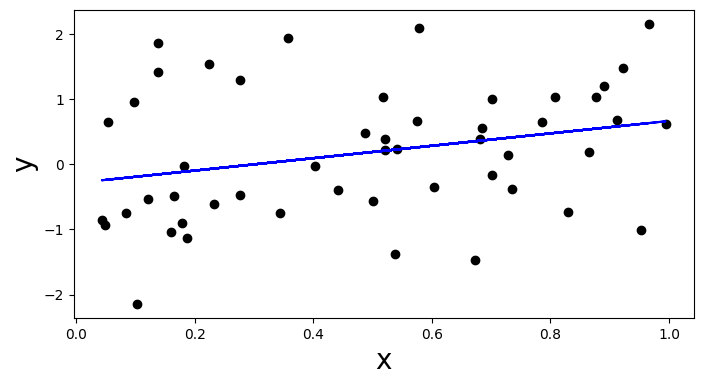

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     4.082
Date:                Thu, 19 Mar 2026   Prob (F-statistic):             0.0489
Time:                        21:21:18   Log-Likelihood:                -69.189
No. Observations:                  50   AIC:                             142.4
Df Residuals:                      48   BIC:                             146.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2883      0.268     -1.075      0.2

In [606]:
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols

# dados
n = 50
x = np.random.uniform(0, 1,n)
y = np.random.normal(0,1, n)
data = pd.DataFrame({'x': x, 'y': y})

# ajusta o modelo de regressão linear
x = x.reshape(-1, 1)
reg = LinearRegression().fit(x, y)
y_predicted = reg.predict(x)

# Mostra os resultados
plt.figure(figsize=(8,4))
plt.plot(x, y, 'o', color='black');
plt.plot(x,y_predicted,color='blue')
plt.xlabel('x', fontsize = 20)
plt.ylabel('y', fontsize = 20)
plt.savefig('regress-random.svg')
plt.show(True)

# sumários estatístico com OLS
model = ols("y ~ x", data).fit()
print(model.summary())

No caso multivariado:

In [607]:
from statsmodels.formula.api import ols
import pandas as pd
import numpy as np
np.random.seed(10)

n = 500 # número de observações
# gera os dados
x1 = np.random.uniform(0,10, (n, 1));
x2 = np.random.uniform(0,10, (n, 1));
x3 = np.random.uniform(1,10, (n, 1));
e = np.random.normal(0,5, (n, 1))
y = 5 + 2*x1 + 3*x2 + e

X = np.hstack((x1,x2,x3,y))
data = pd.DataFrame(X, columns = ['x1', 'x2','x3','y'])

# sumários estatístico com o OLS
model = ols(formula='y ~ x1 + x2 + x3', data = data).fit()
print(model.summary())
print('Parâmetros:\n', model.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     916.3
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          8.25e-202
Time:                        21:21:18   Log-Likelihood:                -1507.3
No. Observations:                 500   AIC:                             3023.
Df Residuals:                     496   BIC:                             3039.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2219      0.709      5.953      0.0

### Inferência sobre o modelo em um conjunto de dados

In [608]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
np.random.seed(101)

# le os dados
# se for lear do hard disk: ############################
data = pd.read_csv('data/Advertising.csv', header=(0), index_col=[0])

# Se for lear do Google Drive: ############################
#from google.colab import drive
#drive.mount('/content/drive/')

#file_path = '/content/drive/MyDrive/data/Advertising.csv'
#try:
#    data = pd.read_csv(file_path)
#    print(data.head()) # Print the first 5 rows of the DataFrame
#except FileNotFoundError:
#    print(f"Error: The file was not found at {file_path}")
############################



# valor a ser predito
ylabel = data.columns[-1]
print("Número de linhas e colunas:", data.shape)
data.head(10)

# monta o modelo: y ~ x1 + x2 + ...
model_string =  data.columns[0]
features = data.columns[1:-1]
for s in features:
    model_string = model_string + '+' + s
model_string = data.columns[-1] + '~' + model_string
print('Modelo as ser ajustado: ', model_string)

model = ols(model_string, data).fit()
print(model.summary())

Número de linhas e colunas: (200, 4)
Modelo as ser ajustado:  sales~TV+radio+newspaper
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.58e-96
Time:                        21:21:18   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

## Diagnóstico

Após o ajuste do modelo, é importante realizar um diagnóstico com relação ao que foi assumido na sua elaboração. Quando realizamos a inferência, vimos que  assumimos que os erros são normalmente distribuídos. Desse modo, é esperando que os resíduos sejam normalmente distribuídos com média igual a zero. Verificamos essa propriedade no histograma a seguir.

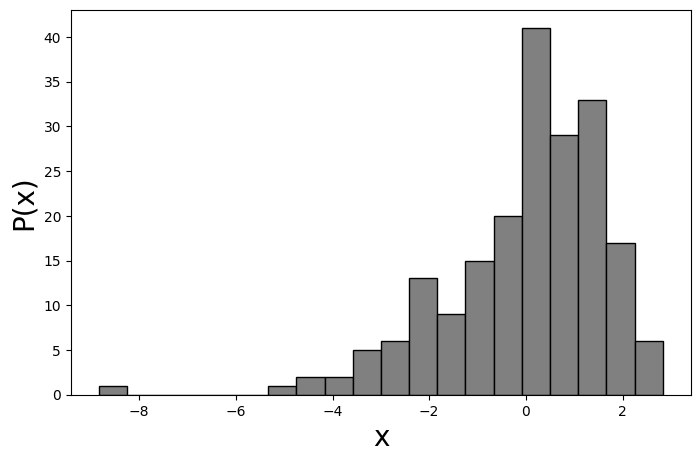

In [609]:
plt.figure(figsize=(8,5))
residuals = model.resid

plt.hist(residuals, bins=20, color = 'gray', histtype='bar', ec='black')
plt.xlabel('x', fontsize = 20)
plt.ylabel('P(x)',fontsize = 20)
plt.show(True)

Também podemos construir um gráfico quantil-quantil para verificar se a distribuição dos resíduos se aproxima de uma normal.

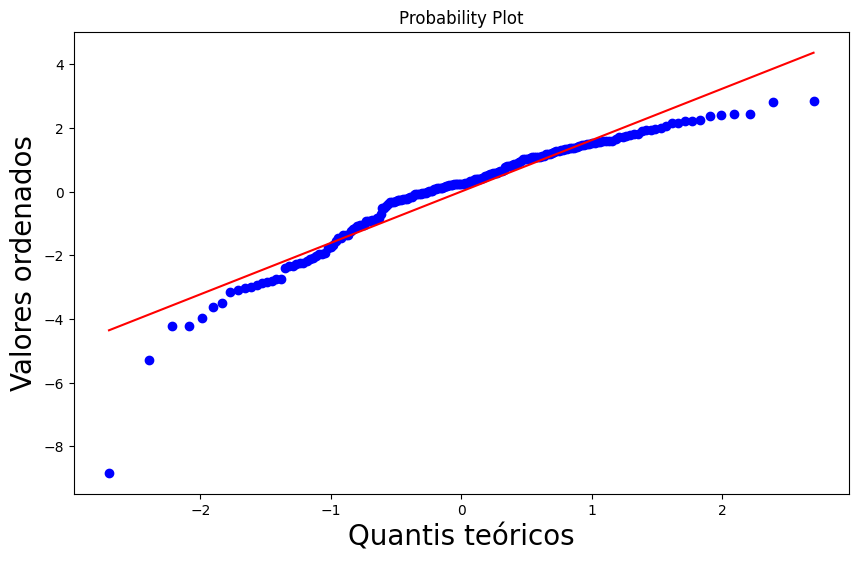

In [610]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
stats.probplot(np.sort(residuals), dist="norm",plot=plt)

plt.xlabel('Quantis teóricos', fontsize = 20)
plt.ylabel('Valores ordenados',fontsize = 20)
plt.savefig('QQ.svg')
plt.show(True)

Finalmente, podemos mostrar os resíduos em função dos valores preditos. Espera-se que os resíduos sejam aleatoriamente distribuídos em torno de zero.


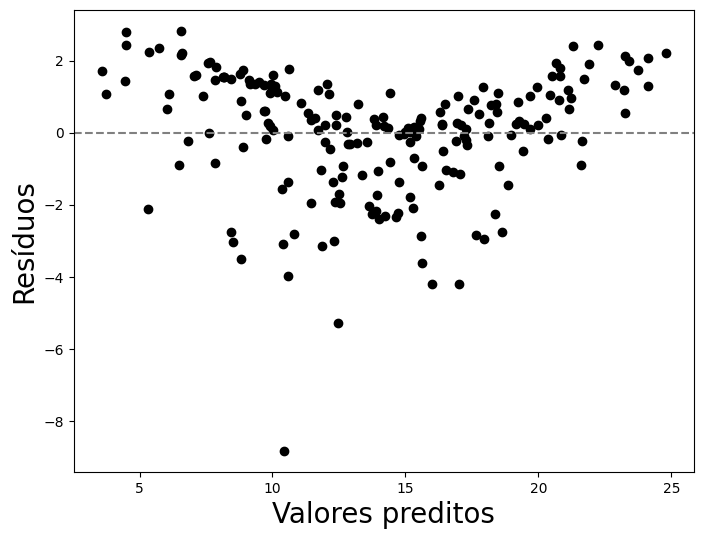

In [611]:
plt.figure(figsize=(8,6))

plt.scatter(model.fittedvalues, residuals,color='black')
plt.axhline(y = 0, color = 'gray', linestyle = '--')
plt.xlabel('Valores preditos',fontsize = 20)
plt.ylabel('Resíduos', fontsize = 20)
plt.savefig('residuos-diagnosis.svg')
plt.show(True)

## **Exercícios para entregar**

1 - Para os dados gerados pelo código abaixo, ajuste um modelo de regressão polinomial considerando um polinômio de grau 3 e 5. Qual oferece o melhor ajuste em termos do coeficiente R2?

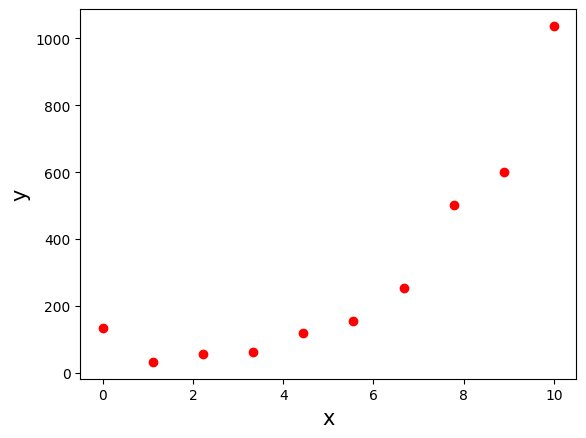

In [612]:
import numpy as np
from sklearn.linear_model import LinearRegression

N = 10
x = np.linspace(0,10,N)
y = x**3 + np.random.normal(0,50, N)
plt.plot(x,y, 'ro')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)

plt.show(True)

In [613]:
# Coloque o código aqui
#polinomio de grau 3
transf3 = PolynomialFeatures(degree=3, include_bias=False)
x = x.reshape((-1,1))
transf3.fit(x)

print("Dados originais: \n", x)

#aplicando a transformação
x_3 = transf3.transform(x)
print("Novos dados: \n", x_3)

#aplicando a regressao linear
modelo= LinearRegression().fit(x_3,y)
y_predito = modelo.predict(x_3)


Dados originais: 
 [[ 0.        ]
 [ 1.11111111]
 [ 2.22222222]
 [ 3.33333333]
 [ 4.44444444]
 [ 5.55555556]
 [ 6.66666667]
 [ 7.77777778]
 [ 8.88888889]
 [10.        ]]
Novos dados: 
 [[   0.            0.            0.        ]
 [   1.11111111    1.2345679     1.37174211]
 [   2.22222222    4.9382716    10.9739369 ]
 [   3.33333333   11.11111111   37.03703704]
 [   4.44444444   19.75308642   87.7914952 ]
 [   5.55555556   30.86419753  171.46776406]
 [   6.66666667   44.44444444  296.2962963 ]
 [   7.77777778   60.49382716  470.50754458]
 [   8.88888889   79.01234568  702.33196159]
 [  10.          100.         1000.        ]]


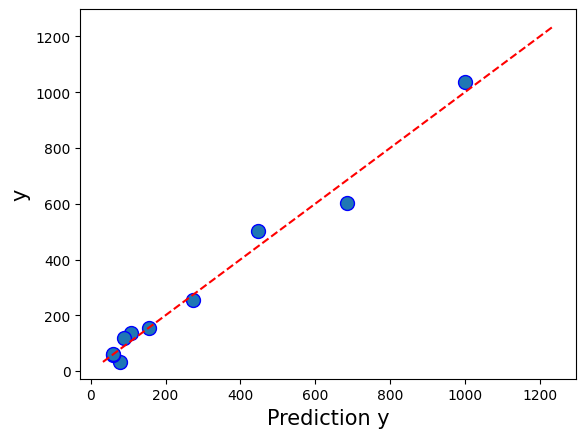

In [614]:
#visualização dos graficos linear e cubico
fig = plt.figure()
l = plt.plot(y_predito, y, 'bo')
plt.setp(l, markersize=10)
plt.setp(l, markerfacecolor='C0')

plt.ylabel("y", fontsize=15)
plt.xlabel("Prediction y", fontsize=15)

# mostra a reta diagonal, que representa a predição perfeita
xl = np.arange(min(y), 1.2*max(y),(max(y)-min(y))/10)
yl = xl
plt.plot(xl, yl, 'r--')

plt.show(True)

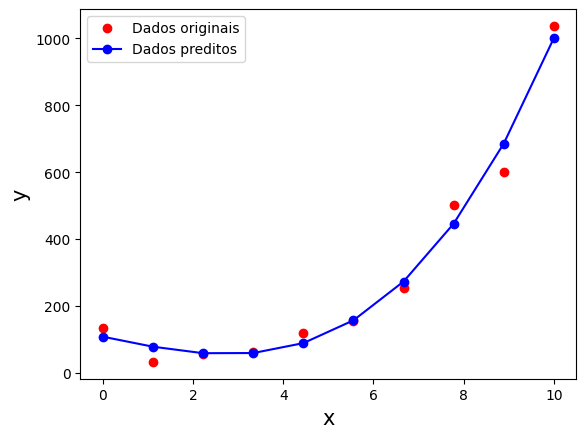

In [615]:
plt.plot(x,y, 'ro', label='Dados originais')
plt.plot(x,y_predito, 'bo-', label = 'Dados preditos')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)
plt.legend()
plt.show(True)

In [616]:
#calculo do R² pro caso cubico

R2_cubico = r2_score(y, y_predito)
print("R2 cubico: ", R2_cubico)

R2 cubico:  0.9835154829103776


In [617]:
#polinomio de grau 3
transf5 = PolynomialFeatures(degree=5, include_bias=False)
x = x.reshape((-1,1))
transf5.fit(x)

print("Dados originais: \n", x)

#aplicando a transformação
x_5 = transf5.transform(x)
print("Novos dados: \n", x_5)

#aplicando a regressao linear
modelo= LinearRegression().fit(x_5,y)
y_predito5 = modelo.predict(x_5)

Dados originais: 
 [[ 0.        ]
 [ 1.11111111]
 [ 2.22222222]
 [ 3.33333333]
 [ 4.44444444]
 [ 5.55555556]
 [ 6.66666667]
 [ 7.77777778]
 [ 8.88888889]
 [10.        ]]
Novos dados: 
 [[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [1.11111111e+00 1.23456790e+00 1.37174211e+00 1.52415790e+00
  1.69350878e+00]
 [2.22222222e+00 4.93827160e+00 1.09739369e+01 2.43865264e+01
  5.41922810e+01]
 [3.33333333e+00 1.11111111e+01 3.70370370e+01 1.23456790e+02
  4.11522634e+02]
 [4.44444444e+00 1.97530864e+01 8.77914952e+01 3.90184423e+02
  1.73415299e+03]
 [5.55555556e+00 3.08641975e+01 1.71467764e+02 9.52598689e+02
  5.29221494e+03]
 [6.66666667e+00 4.44444444e+01 2.96296296e+02 1.97530864e+03
  1.31687243e+04]
 [7.77777778e+00 6.04938272e+01 4.70507545e+02 3.65950312e+03
  2.84628021e+04]
 [8.88888889e+00 7.90123457e+01 7.02331962e+02 6.24295077e+03
  5.54928957e+04]
 [1.00000000e+01 1.00000000e+02 1.00000000e+03 1.00000000e+04
  1.00000000e+05]]


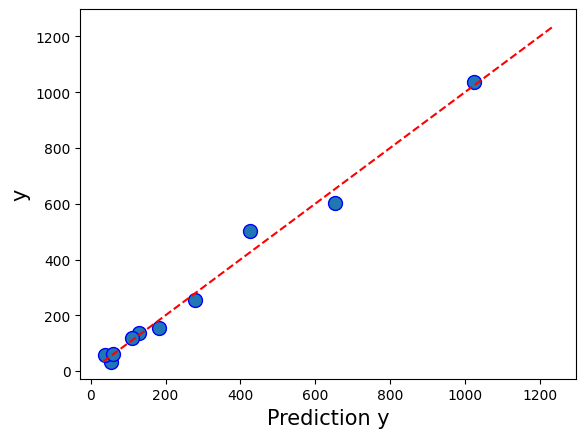

In [618]:
#visualização dos graficos linear e grau 5
fig = plt.figure()
l = plt.plot(y_predito5, y, 'bo')
plt.setp(l, markersize=10)
plt.setp(l, markerfacecolor='C0')

plt.ylabel("y", fontsize=15)
plt.xlabel("Prediction y", fontsize=15)

# mostra a reta diagonal, que representa a predição perfeita
xl = np.arange(min(y), 1.2*max(y),(max(y)-min(y))/10)
yl = xl
plt.plot(xl, yl, 'r--')

plt.show(True)

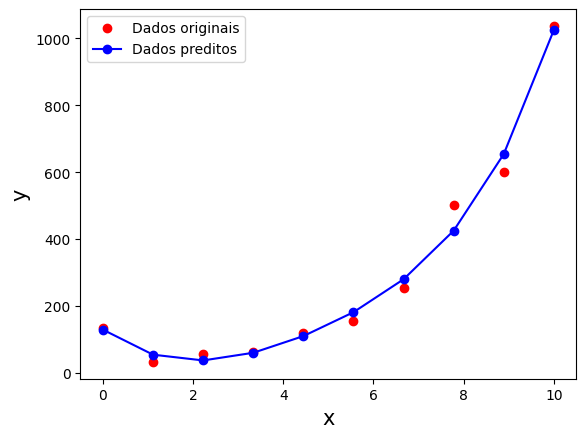

In [619]:
plt.plot(x,y, 'ro', label='Dados originais')
plt.plot(x,y_predito5, 'bo-', label = 'Dados preditos')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)
plt.legend()
plt.show(True)

In [620]:
#calculo do R² pro caso cubico

R2_g5 = r2_score(y, y_predito5)
print("R2 cubico: ", R2_g5)

R2 cubico:  0.9883551550586152


 2 - O que acontece com os coeficientes do modelo se normalizamos ou padronizarmos os dados?
 Faça uma análise usando dados do UCI: https://archive.ics.uci.edu/



In [621]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [622]:
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [623]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine = fetch_ucirepo(id=186) 
data = wine.data.original

print(data.head())


   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality color  
0      9.4        5   red  
1      9.8        5   red  
2 

In [624]:
print(data.info())
print(data.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB
None
fixed_acidity           0
volatile_acidity        0
citric_acid          

In [625]:
print(data.columns)


Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'color'],
      dtype='str')


In [626]:
X = data.drop(columns=['quality'])
X['color'] = X['color'].map({'red': 0, 'white': 1})
y =  data['quality']

In [627]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler() #padroniza
normaler = MinMaxScaler() #normaliza

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_norm = normaler.fit_transform(X_train)
X_test_norm = normaler.transform(X_test)

In [628]:
print("Original: " ,X_train.iloc[0].values)
print("Padronizado: ", X_train_scaled[0,])
print("Normalizado: ",X_train_norm[0,])

Original:  [7.100e+00 1.200e-01 3.200e-01 9.600e+00 5.400e-02 6.400e+01 1.620e+02
 9.962e-01 3.400e+00 4.100e-01 9.400e+00 1.000e+00]
Padronizado:  [-7.51682345e-02 -1.33696832e+00  8.58590678e-04  8.62292481e-01
 -4.50232752e-02  1.92023423e+00  8.33668553e-01  5.05081859e-01
  1.14171148e+00 -8.17593880e-01 -9.07381844e-01  5.61073636e-01]
Normalizado:  [0.27966102 0.02666667 0.32       0.13803681 0.07475083 0.43298969
 0.46153846 0.17524581 0.51968504 0.10982659 0.23140496 1.        ]


In [629]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

model_n = LinearRegression()
model_n.fit(X_train_norm, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [630]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred_scaled = model.predict(X_test_scaled)
y_pred_norm = model_n.predict(X_test_norm)

print("R2 - Scaled:", r2_score(y_test, y_pred_scaled))
print("R2 - Normalizado:", r2_score(y_test, y_pred_norm))
print("MSE - Scaled:", mean_squared_error(y_test, y_pred_scaled))
print("MSE - Normalizado:", mean_squared_error(y_test, y_pred_norm))


R2 - Scaled: 0.279613543257627
R2 - Normalizado: 0.279613543257627
MSE - Scaled: 0.5326149345468385
MSE - Normalizado: 0.5326149345468385


Como é possível ver nos resultados acima, não faz diferenças padronizar ou normalizar o dados neste contexto, logo que no problema de regressão, cada coeficiente Bi depende da escala da variável Xi.

3 - Os coeficientes do modelo medem a importância dos atributos? Elabore um experimento para analisar essa questão.

In [631]:
# Coloque o código 
#Sem Padronização
modelo = LinearRegression()
modelo.fit(X_train, y_train)

coef =  modelo.coef_

#Com Padronização
modelo_scaled = LinearRegression()
modelo_scaled.fit(X_train_scaled, y_train)

coef_scaled =  modelo_scaled.coef_


#Comparação dos resultado

compara = pd.DataFrame({'feature':X.columns, 'sem padronização': coef, 'com padronização': coef_scaled})
print(compara.sort_values(by='com padronização', key=abs, ascending=False))

                 feature  sem padronização  com padronização
3         residual_sugar          0.065037          0.311955
7                density       -100.616519         -0.303756
10               alcohol          0.237092          0.283018
1       volatile_acidity         -1.535716         -0.248233
11                 color         -0.318079         -0.135736
9              sulphates          0.798675          0.116153
0          fixed_acidity          0.086396          0.110712
5    free_sulfur_dioxide          0.005636          0.098397
6   total_sulfur_dioxide         -0.001706         -0.095209
8                     pH          0.480284          0.076739
2            citric_acid         -0.087074         -0.012584
4              chlorides         -0.279037         -0.009342


Sem a padronização, os coeficiente possuem bastante variação de grandeza, impedindo uma interpretação precisa dos resultados. Já com a padronização, conseguimos comparar os elementos e analisar cada atributo. 

4 -  Como predizer séries temporais usando modelos de regressão? Construa um exemplo.

A resolução deste exercicio foi baseada num artigo do blog [GeekForGeeks](https://www.geeksforgeeks.org/data-science/time-series-regression/)

In [632]:
# Coloque o código aqui
df = pd.read_csv("daily-website-visitors.csv")

df['Date'] = pd.to_datetime(df['Date']) #convertendo para data e hora
df = df.sort_values('Date')

cols_to_clean = ['Page.Loads', 'Unique.Visits',
                 'First.Time.Visits', 'Returning.Visits']

for col in cols_to_clean:
    df[col] = df[col].str.replace(',', '').astype(int)#retirando os marks do csv(,)

df.set_index('Date', inplace=True)
df.head()

,Row,Day,Day.Of.Week,Page.Loads,Unique.Visits,First.Time.Visits,Returning.Visits
Date,,,,,,,
2014-09-14,1,Sunday,1,2146,1582,1430,152
2014-09-15,2,Monday,2,3621,2528,2297,231
2014-09-16,3,Tuesday,3,3698,2630,2352,278
2014-09-17,4,Wednesday,4,3667,2614,2327,287
2014-09-18,5,Thursday,5,3316,2366,2130,236


In [633]:
#Variaveis de atraso - representarao os dados de um dia e dois dias anteriores
#Os valores Lag1 e Lag2 são criados deslocando a coluna original 'Vendas' em 1 e 2 posiçõe
df['Lag1'] = df['Unique.Visits'].shift(1)
df['Lag2'] = df['Unique.Visits'].shift(2)

df = df.dropna()
df[['Unique.Visits', 'Lag1', 'Lag2']].head()

,Unique.Visits,Lag1,Lag2
Date,,,
2014-09-16,2630,2528.0,1582.0
2014-09-17,2614,2630.0,2528.0
2014-09-18,2366,2614.0,2630.0
2014-09-19,1863,2366.0,2614.0
2014-09-20,1118,1863.0,2366.0


In [634]:
#dividindo os dados em treinamento e teste
X = df[['Lag1', 'Lag2']]
y = df['Unique.Visits']


split_point = int(len(df) * 0.8)
X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

X_train.head()
X_test.head()

,Lag1,Lag2
Date,,
2019-06-14,2844.0,3064.0
2019-06-15,2265.0,2844.0
2019-06-16,1467.0,2265.0
2019-06-17,1747.0,1467.0
2019-06-18,2925.0,1747.0


In [635]:
#treinando o modelo de Regressão Linear
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Intercepto:", modelo.intercept_)
print("Coeficientes:", modelo.coef_)


Intercepto: 1069.5781561892477
Coeficientes: [ 1.12566875 -0.49146525]


In [636]:
y_pred = modelo.predict(X_test)

print(pd.DataFrame({
    'Atual': y_test.head().values,
    'Previsto': y_pred[:5]
}))

   Atual     Previsto
0   2265  2765.130537
1   1467  2221.490688
2   1747  1607.765409
3   2925  2315.141931
4   3013  3503.569444


In [637]:
#avaliando o desempenho 
mse = mean_squared_error(y_test, y_pred)
print(f"Erro quadratico medio: {mse}")

Erro quadratico medio: 271129.8881000108


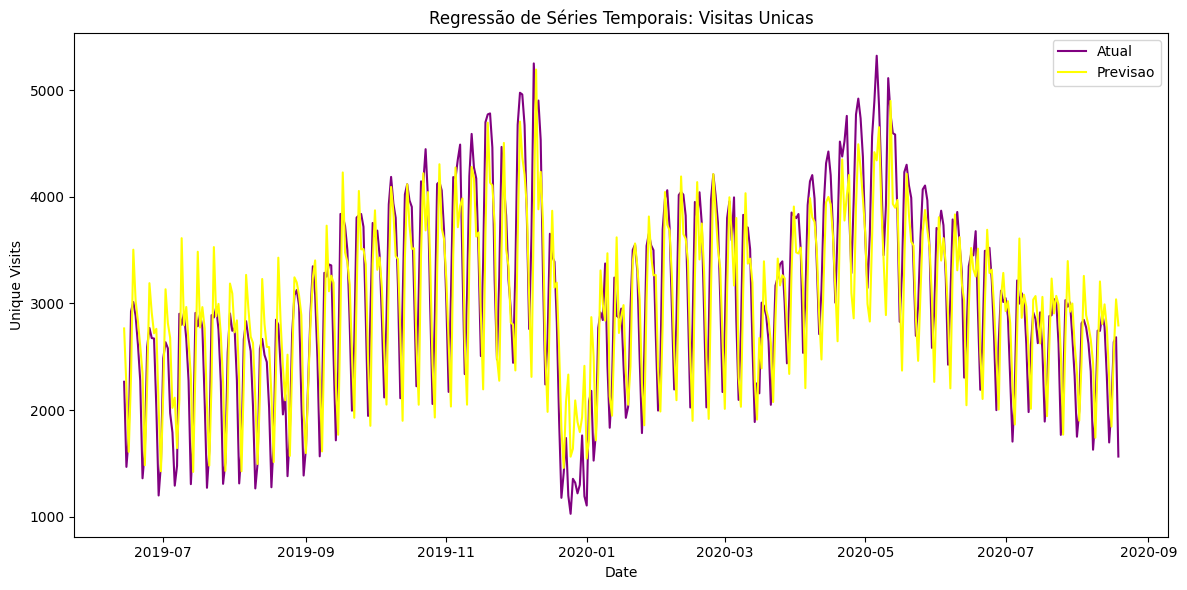

In [638]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Atual', color='purple')
plt.plot(y_test.index, y_pred, label='Previsao', color='yellow')
plt.title('Regressão de Séries Temporais: Visitas Unicas')
plt.xlabel('Date')
plt.ylabel('Unique Visits')
plt.legend()
plt.tight_layout()
plt.show()

5 - Selecione uma base de séries temporais da UCI e faça a predição.

In [639]:
# Coloque o código aqui
  
# fetch dataset 
metro_interstate_traffic_volume = fetch_ucirepo(id=492) 
  
# data (as pandas dataframes) 
X = metro_interstate_traffic_volume.data.features 
y = metro_interstate_traffic_volume.data.targets 
  
# metadata 
print(metro_interstate_traffic_volume.metadata) 
  
# variable information 
print(metro_interstate_traffic_volume.variables) 


{'uci_id': 492, 'name': 'Metro Interstate Traffic Volume', 'repository_url': 'https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume', 'data_url': 'https://archive.ics.uci.edu/static/public/492/data.csv', 'abstract': 'Hourly Minneapolis-St Paul, MN traffic volume for westbound I-94. Includes weather and holiday features from 2012-2018.', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 48204, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['traffic_volume'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C5X60B', 'creators': ['John Hogue'], 'intro_paper': None, 'additional_info': {'summary': 'Hourly Interstate 94 Westbound traffic volume for MN DoT ATR station 301, roughly midway between Minneapolis and St Paul, MN. Hourly weath

In [640]:
df_metro = metro_interstate_traffic_volume.data.original
df_metro.head(5)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [641]:
#verificando a intergidade do dataset
print(df_metro.info())
print(df_metro.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB
None
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


In [642]:
df_metro['date_time'] = pd.to_datetime(df_metro['date_time']) #convertendo para data e hora
df_metro = df_metro.sort_values('date_time')
df_metro.set_index('date_time', inplace=True)
df_metro.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume
date_time,,,,,,,,
2012-10-02 09:00:00,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,5545
2012-10-02 10:00:00,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,4516
2012-10-02 11:00:00,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,4767
2012-10-02 12:00:00,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,5026
2012-10-02 13:00:00,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,4918


In [648]:
# remover duplicatas
df_metro = df_metro.groupby(df_metro.index).mean(numeric_only=True)

# garantir frequência horária
df_metro = df_metro.asfreq('h')

# preencher dados
df_metro['traffic_volume'] = df_metro['traffic_volume'].interpolate()
df_metro = df_metro.ffill()

In [649]:
#subdivindo date_time em horario, dia da semana, mes e se é feriado
df_metro['hour'] = df_metro.index.hour
df_metro['day_of_week'] = df_metro.index.dayofweek
df_metro['month'] = df_metro.index.month
df_metro['is_weekend'] = (df_metro['day_of_week'] >= 5).astype(int)
df_metro.head()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,day_of_week,month,is_weekend
date_time,,,,,,,,,
2012-10-02 09:00:00,288.28,0.0,0.0,40.0,5545.0,9,1,10,0
2012-10-02 10:00:00,289.36,0.0,0.0,75.0,4516.0,10,1,10,0
2012-10-02 11:00:00,289.58,0.0,0.0,90.0,4767.0,11,1,10,0
2012-10-02 12:00:00,290.13,0.0,0.0,90.0,5026.0,12,1,10,0
2012-10-02 13:00:00,291.14,0.0,0.0,75.0,4918.0,13,1,10,0


In [650]:
print(df_metro.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 52551 entries, 2012-10-02 09:00:00 to 2018-09-30 23:00:00
Freq: h
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temp            52551 non-null  float64
 1   rain_1h         52551 non-null  float64
 2   snow_1h         52551 non-null  float64
 3   clouds_all      52551 non-null  float64
 4   traffic_volume  52551 non-null  float64
 5   hour            52551 non-null  int32  
 6   day_of_week     52551 non-null  int32  
 7   month           52551 non-null  int32  
 8   is_weekend      52551 non-null  int64  
dtypes: float64(5), int32(3), int64(1)
memory usage: 3.4 MB
None


In [651]:
#Criando memoria 
df_metro['lag_1'] = df_metro['traffic_volume'].shift(1) #1 hora anterior
df_metro['lag_24'] = df_metro['traffic_volume'].shift(24) #24 horas anteriores

#media movel - reduz os ruidos
df_metro['rolling_mean_24'] = df_metro['traffic_volume'].shift(1).rolling(24).mean()

df_metro = df_metro.dropna()

In [652]:
df_metro[['traffic_volume', 'lag_1', 'lag_24', 'rolling_mean_24']].head()

,traffic_volume,lag_1,lag_24,rolling_mean_24
date_time,,,,
2012-10-03 09:00:00,5471.000000,6511.000000,5545.0,3606.833333
2012-10-03 10:00:00,5346.333333,5471.000000,4516.0,3603.750000
2012-10-03 11:00:00,5221.666667,5346.333333,4767.0,3638.347222
2012-10-03 12:00:00,5097.000000,5221.666667,5026.0,3657.291667
2012-10-03 13:00:00,4887.000000,5097.000000,4918.0,3660.250000


In [654]:
#definindo as features de entradas e a saida esperada do modelo
features = [
    'temp', 'rain_1h', 'snow_1h', 'clouds_all',
    'hour', 'day_of_week', 'month', 'is_weekend',
    'lag_1', 'lag_24', 'rolling_mean_24'
]
X = df_metro[features]
y = df_metro['traffic_volume']

#definindo o limiar treinamento/test seguindo o padro 80-20% do total de amostras
split_point = int(len(df_metro) * 0.8)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]

y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

X_train.head()


,temp,rain_1h,snow_1h,clouds_all,hour,day_of_week,month,is_weekend,lag_1,lag_24,rolling_mean_24
date_time,,,,,,,,,,,
2012-10-03 09:00:00,282.48,0.0,0.0,1.0,9,2,10,0,6511.000000,5545.0,3606.833333
2012-10-03 10:00:00,282.48,0.0,0.0,1.0,10,2,10,0,5471.000000,4516.0,3603.750000
2012-10-03 11:00:00,282.48,0.0,0.0,1.0,11,2,10,0,5346.333333,4767.0,3638.347222
2012-10-03 12:00:00,291.97,0.0,0.0,1.0,12,2,10,0,5221.666667,5026.0,3657.291667
2012-10-03 13:00:00,293.23,0.0,0.0,1.0,13,2,10,0,5097.000000,4918.0,3660.250000


In [656]:
X_test.head()

,temp,rain_1h,snow_1h,clouds_all,hour,day_of_week,month,is_weekend,lag_1,lag_24,rolling_mean_24
date_time,,,,,,,,,,,
2017-07-20 06:00:00,292.23,0.0,0.0,1.0,6,3,7,0,3008.0,5944.0,3763.916667
2017-07-20 07:00:00,292.28,0.0,0.0,20.0,7,3,7,0,5862.0,6447.0,3760.500000
2017-07-20 08:00:00,293.15,0.0,0.0,75.0,8,3,7,0,6446.0,5899.0,3760.458333
2017-07-20 09:00:00,294.37,0.0,0.0,75.0,9,3,7,0,6317.0,5100.0,3777.875000
2017-07-20 10:00:00,295.22,0.0,0.0,75.0,10,3,7,0,5051.0,4681.0,3775.833333


In [663]:
#usando o pipelina
from sklearn.pipeline import Pipeline

In [670]:
#treinando o modelo de Regressão Linear
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", np.sqrt(mse))


MSE: 380971.79477773595
RMSE: 617.229126644017


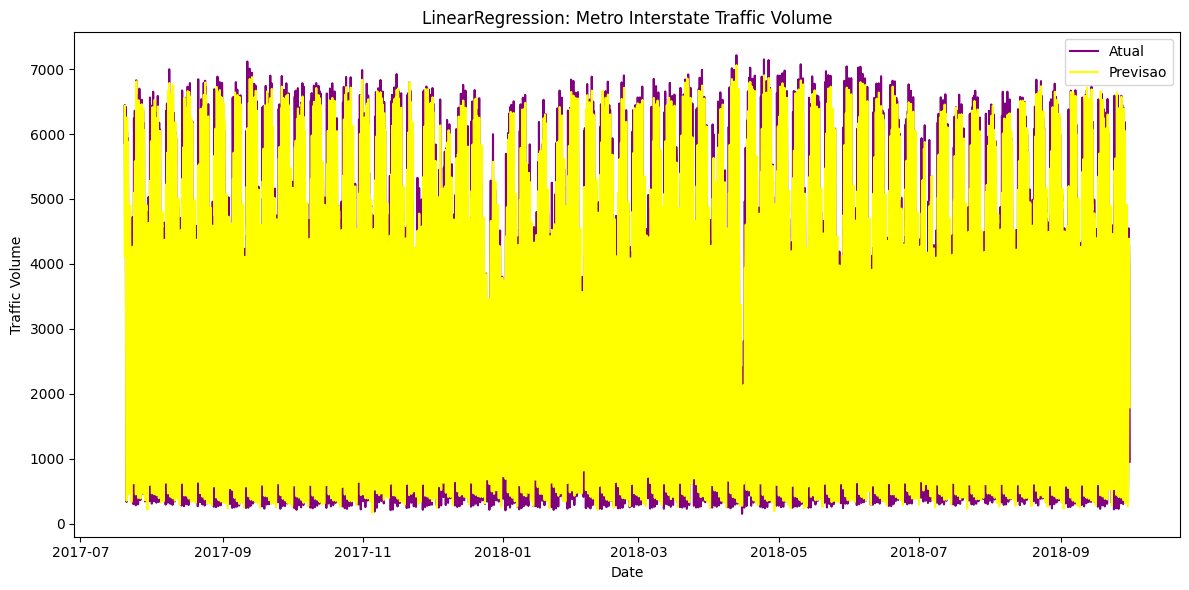

In [671]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Atual', color='purple')
plt.plot(y_test.index, y_pred, label='Previsao', color='yellow')
plt.title('LinearRegression: Metro Interstate Traffic Volume')
plt.xlabel('Date')
plt.ylabel('Traffic Volume')
plt.legend()
plt.tight_layout()
plt.show()

In [672]:
from sklearn.ensemble import RandomForestRegressor

pipeline2 = Pipeline([
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeline2.fit(X_train, y_train)

y_pred2 = pipeline2.predict(X_test)

mse = mean_squared_error(y_test, y_pred2)

print("MSE:", mse)
print("RMSE:", np.sqrt(mse))


MSE: 59871.41577540147
RMSE: 244.68636205436843


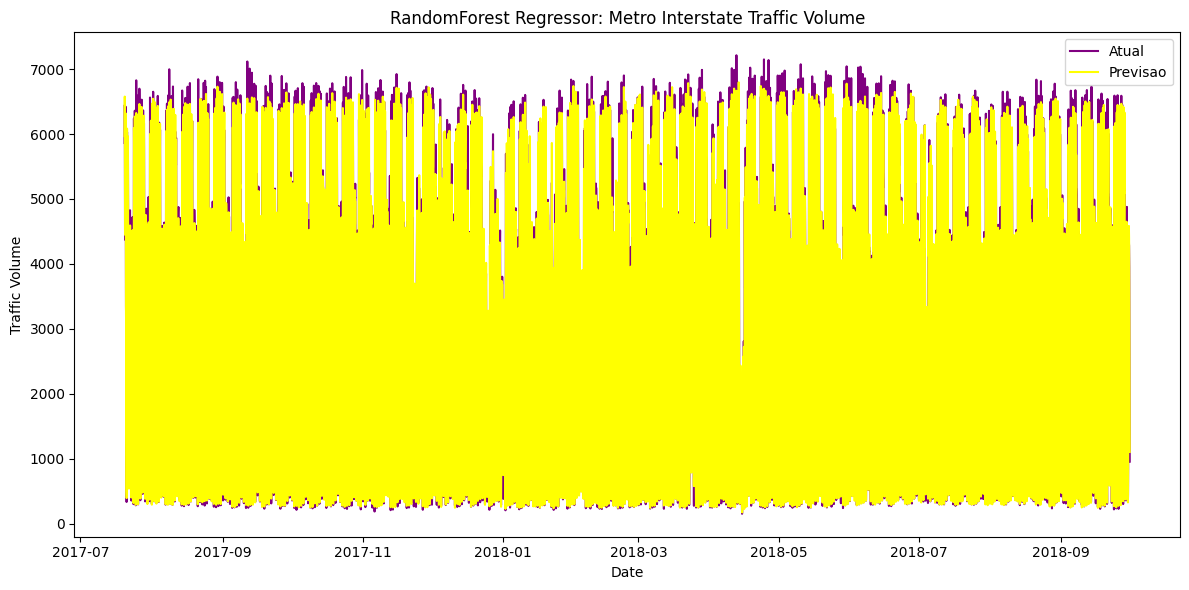

In [673]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Atual', color='purple')
plt.plot(y_test.index, y_pred2, label='Previsao', color='yellow')
plt.title('RandomForest Regressor: Metro Interstate Traffic Volume')
plt.xlabel('Date')
plt.ylabel('Traffic Volume')
plt.legend()
plt.tight_layout()
plt.show()

#### Coisas legais sobre os dados do dataset

<Axes: xlabel='hour'>

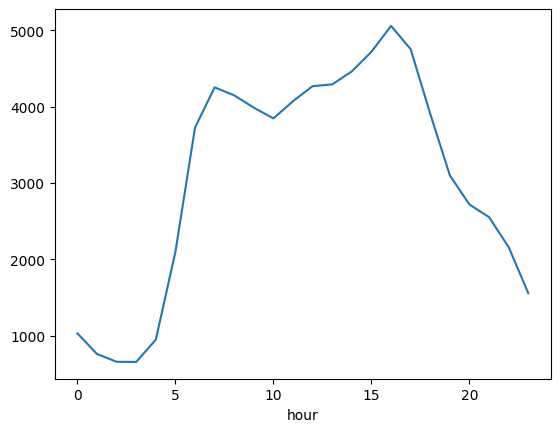

In [674]:
df_metro.groupby('hour')['traffic_volume'].mean().plot()

<Axes: xlabel='rain_1h'>

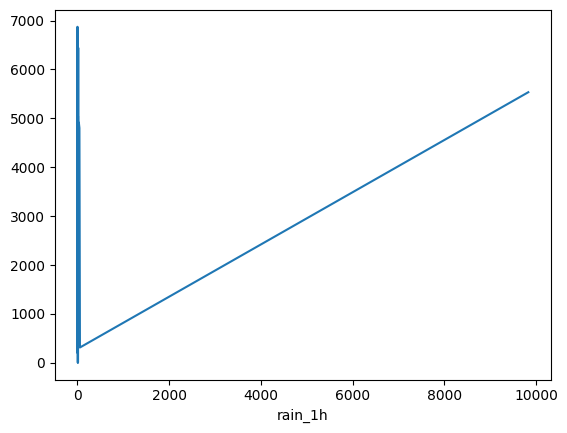

In [676]:
df_metro.groupby('rain_1h')['traffic_volume'].mean().plot()

<Axes: xlabel='rain_category'>

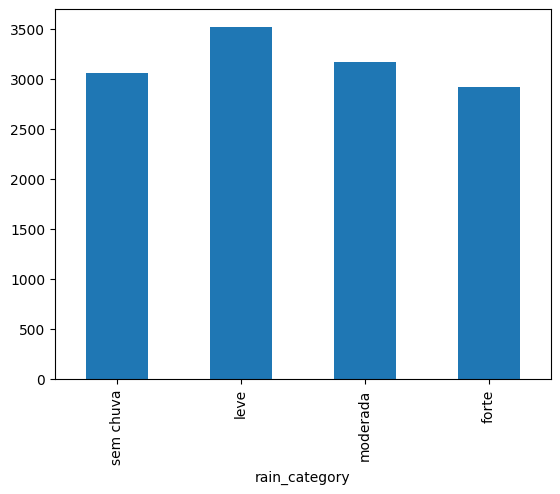

In [677]:
df_metro['rain_category'] = pd.cut(
    df_metro['rain_1h'],
    bins=[-0.1, 0, 1, 5, 20],
    labels=['sem chuva', 'leve', 'moderada', 'forte']
)

df_metro.groupby('rain_category')['traffic_volume'].mean().plot(kind='bar')

<Axes: xlabel='clouds_all'>

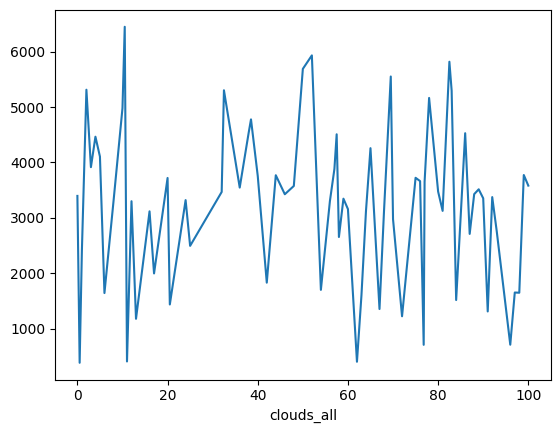

In [678]:
df_metro.groupby('clouds_all')['traffic_volume'].mean().plot()

<Axes: xlabel='clouds_cat'>

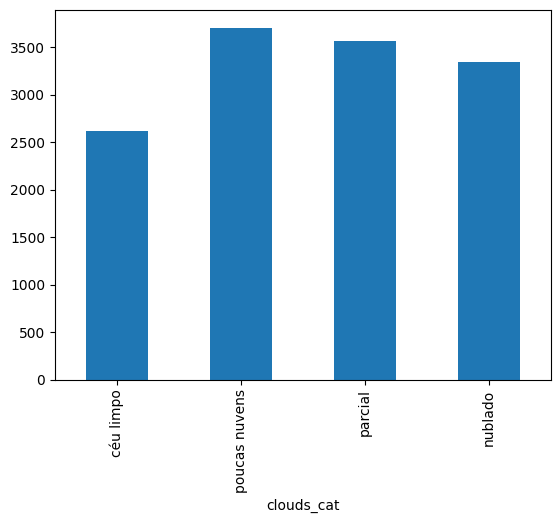

In [679]:
df_metro['clouds_cat'] = pd.cut(
    df_metro['clouds_all'],
    bins=[0, 20, 50, 80, 100],
    labels=['céu limpo', 'poucas nuvens', 'parcial', 'nublado']
)

df_metro.groupby('clouds_cat')['traffic_volume'].mean().plot(kind='bar')

<Axes: xlabel='day_of_week', ylabel='hour'>

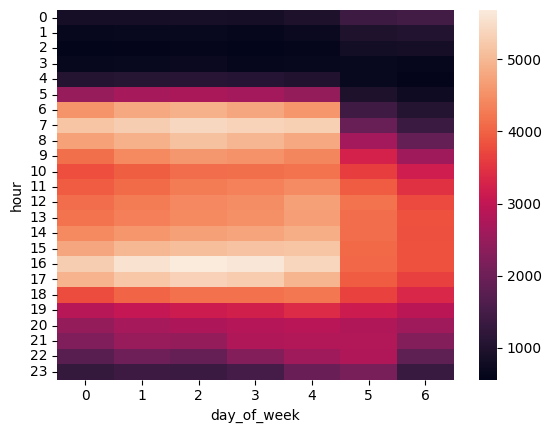

In [683]:
import seaborn as sns

pivot = df_metro.pivot_table(
    values='traffic_volume',
    index='hour',
    columns='day_of_week',
    aggfunc='mean'
)

sns.heatmap(pivot)